<a href="https://colab.research.google.com/github/ravichu/Lab7_Data_Visualization/blob/main/ADDITIONAL_EXERCISES_LAB_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Your info
student_name = "KIM HARRIE PILAPIL BEJAR"
student_id = "TUPM-25-0077"

id_num = int(student_id[-3:])
color_bar = f"#{(id_num * 7) % 256:02x}{(id_num * 3) % 256:02x}{(id_num * 5) % 256:02x}"
color_line = f"#{(id_num * 2) % 256:02x}{(id_num * 9) % 256:02x}{(id_num * 4) % 256:02x}"

# Load dataset
df = pd.read_csv("/content/spotify_top_1000_tracks.csv")

# Preprocess
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year

In [3]:
longest = df.sort_values(by='duration_min', ascending=False).head(10)
longest[['track_name', 'artist', 'duration_min']]

,track_name,artist,duration_min
710,Lost Boy,Jaden,9.497883
610,I'm Getting Ready,Tasha Cobbs Leonard,8.436667
64,Mirrors,Justin Timberlake,8.069100
63,What Goes Around.../...Comes Around (Interlude),Justin Timberlake,7.476217
622,Achilles Come Down,Gang of Youths,7.035767
689,Never Let Go (Of Me),Baltra,6.909833
682,House Of Balloons / Glass Table Girls,The Weeknd,6.753550
549,Stan,Eminem,6.735100
671,Galvanize,The Chemical Brothers,6.563550
37,After Hours,The Weeknd,6.017100


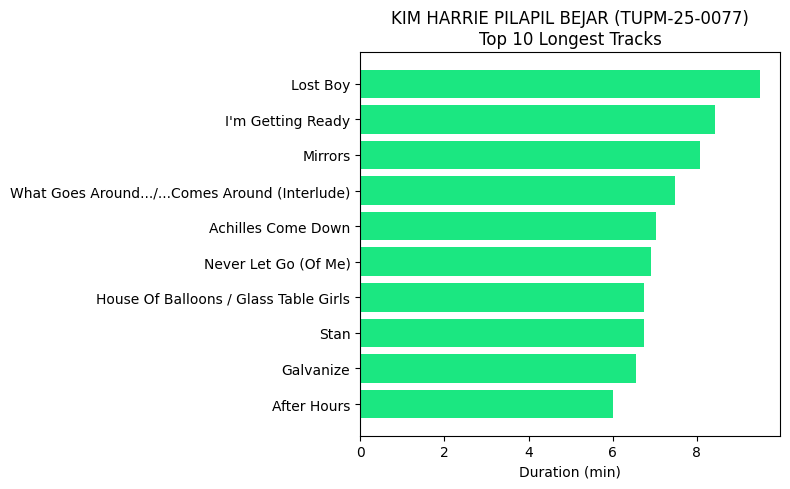

In [4]:
plt.figure(figsize=(8,5))
plt.barh(longest['track_name'], longest['duration_min'], color=color_bar)

plt.xlabel("Duration (min)")
plt.title(f"{student_name} ({student_id})\nTop 10 Longest Tracks")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [5]:
year_counts = df['year'].value_counts().sort_index()

In [6]:
cumulative = year_counts.cumsum()

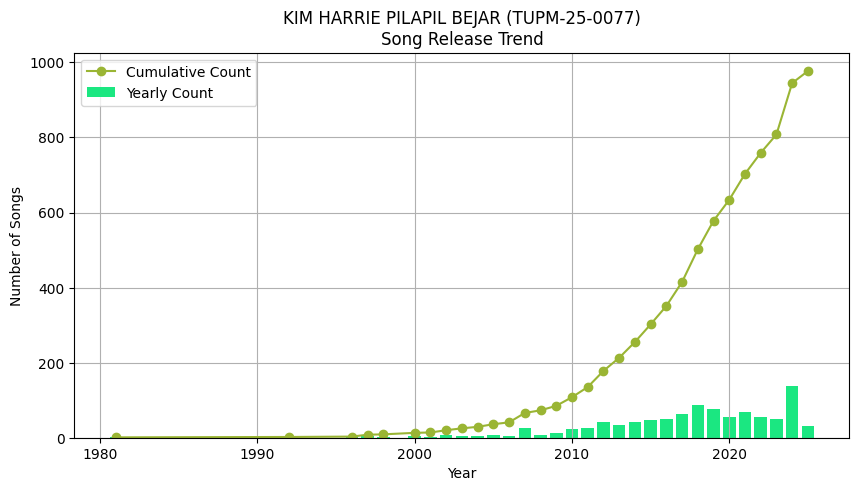

In [7]:
plt.figure(figsize=(10,5))

# Bar
plt.bar(year_counts.index, year_counts.values, color=color_bar, label="Yearly Count")

# Line
plt.plot(cumulative.index, cumulative.values, color=color_line, marker='o', label="Cumulative Count")

plt.title(f"{student_name} ({student_id})\nSong Release Trend")
plt.xlabel("Year")
plt.ylabel("Number of Songs")
plt.legend()
plt.grid(True)

plt.show()

In [8]:
df = df.dropna(subset=['duration_min', 'popularity', 'year'])
years = sorted(df['year'].unique())

In [9]:
from matplotlib.animation import FuncAnimation

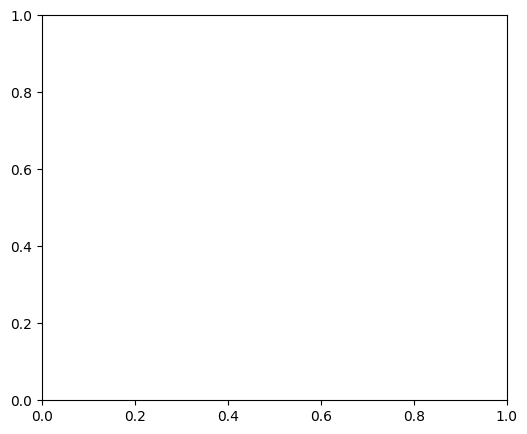

In [10]:
fig, ax = plt.subplots(figsize=(6,5))

In [11]:
def update(year):
    ax.clear()
    data = df[df['year'] == year]

    ax.hexbin(data['duration_min'], data['popularity'],
              gridsize=20, cmap='coolwarm')

    ax.set_title(f"{student_name} ({student_id})\nYear: {year}")
    ax.set_xlabel("Duration (min)")
    ax.set_ylabel("Popularity")

In [12]:
xani = FuncAnimation(fig, update, frames=years, interval=300)

plt.show()

In [13]:
from IPython.display import HTML
HTML(ani.to_jshtml())

NameError: name 'ani' is not defined